# Agent-Guided Test Suite Refinement for Fault Localization

**Hypothesis:** LLM-generated diverse tests (via a similarity-aware test generation agent) combined with algorithmic condensation produce better Tarantula suspiciousness rankings than condensation alone.

**Method:**
1. Check out a buggy BugsInPy version in Docker and run the dynamic tracer (baseline)
2. Extract the buggy module's source code and existing tests
3. Run the test generation agent N times to produce diverse, non-redundant tests
4. Inject the generated tests into the project and re-run the tracer (augmented)
5. Apply condensation to both suites and compare Tarantula rankings

**Agent Architecture (from prior work):**

The test generation agent is a LangGraph pipeline with 5 nodes:
- **write_initial_test** -- generates a test targeting uncovered behavior
- **fix_similarities** -- compares against existing tests via vector store; rewrites if too similar
- **has_test_smell_router** -- routes to fix or keep based on test quality heuristics
- **fix_test_smell** -- rewrites the test to remove identified smells
- **add_to_vectorstore** -- stores the final test so future generations avoid duplicating it

## 1. Configuration

Change `BUG_IDS` or `N_TESTS_PER_BUG` to adjust the experiment scope. Set `GOOGLE_API_KEY` to your Gemini API key.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv("../.env")

PROJECT = "youtube-dl"
BUG_IDS = ["1", "7", "10"]
N_TESTS_PER_BUG = 5

GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY", "")
assert GOOGLE_API_KEY, "Set GOOGLE_API_KEY in .env or environment"

BUGSINPY_ROOT = "../datasets/BugsInPy"
EXPERIMENTS_DIR = "../experiments"
ARTIFACTS_DIR = "../condensation_artifacts"

In [2]:
import json
import os
import shutil
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sys.path.insert(0, os.path.abspath(".."))

from src.test_generation_controller import (
    run_agent_experiment,
    extract_bug_context,
    generate_diverse_tests,
    make_agent_config,
    inject_and_retrace,
    compute_similarity_matrix,
)
from src.condensation import (
    run_condensation_experiment,
    ExperimentResult,
    invert_coverage_matrix,
    compute_tarantula,
    condense_test_suite,
    extract_ground_truth_fqns,
    get_rank,
)
from src.benchmarks.setup_bugsinpy_docker import BugsInPyDockerSandbox
from src.agent.test_generation.utils.code_processing import extract_unit_tests

os.makedirs(ARTIFACTS_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "serif",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.figsize": (8, 4),
})

print(f"Project: {PROJECT}")
print(f"Bug IDs: {BUG_IDS}")
print(f"Tests per bug: {N_TESTS_PER_BUG}")

Project: youtube-dl
Bug IDs: ['1', '7', '10']
Tests per bug: 5


## 2. Run Agent Experiments

For each bug, this cell:
1. Starts a Docker container with the buggy version
2. Runs the baseline dynamic tracer
3. Extracts the buggy module source and existing tests
4. Runs the test generation agent N times (each test avoids similarity with previous ones)
5. Injects generated tests and re-runs the tracer
6. Computes condensation on both the original and augmented suites

In [3]:
experiments = {}

for bid in BUG_IDS:
    print(f"\n{'='*70}")
    print(f"  {PROJECT} #{bid}")
    print(f"{'='*70}")

    result = run_agent_experiment(
        project=PROJECT,
        bug_id=bid,
        n_tests=N_TESTS_PER_BUG,
        google_api_key=GOOGLE_API_KEY,
        bugsinpy_root=BUGSINPY_ROOT,
        experiments_dir=EXPERIMENTS_DIR,
        artifacts_dir=ARTIFACTS_DIR,
    )

    if result:
        experiments[bid] = result
        br = result["baseline_result"]
        ar = result["augmented_result"]
        print(f"\n  Baseline:  {br.num_tests_full} tests → {br.num_tests_condensed} condensed, rank={br.rank_condensed}")
        if ar:
            print(f"  Augmented: {ar.num_tests_full} tests → {ar.num_tests_condensed} condensed, rank={ar.rank_condensed}")
    else:
        print(f"  FAILED")

print(f"\n✓ {len(experiments)}/{len(BUG_IDS)} experiments completed.")

[sandbox_INFO] Starting container python:3.11-slim in detached mode...



  youtube-dl #1


[sandbox_INFO] Container 2e52f6207c45be93bed1fc5297ca0cee23af9f0bdb63e3d178f779c1af94a5aa started
[sandbox_INFO] Installing BugsInPy dependencies in container...


Hit:1 http://deb.debian.org/debian trixie InRelease
Get:2 http://deb.debian.org/debian trixie-updates InRelease [47.3 kB]
Get:3 http://deb.debian.org/debian-security trixie-security InRelease [43.4 kB]
Get:4 http://deb.debian.org/debian trixie/main arm64 Packages [9607 kB]
Get:5 http://deb.debian.org/debian trixie-updates/main arm64 Packages [5404 B]
Get:6 http://deb.debian.org/debian-security trixie-security/main arm64 Packages [113 kB]
Fetched 9817 kB in 2s (5482 kB/s)
Reading package lists...
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  git-man krb5-locales less libbrotli1 libcbor0.10 libcom-err2
  libcurl3t64-gnutls libedit2 liberror-perl libexpat1 libfido2-1
  libgdbm-compat4t64 libgnutls30t64 libgssapi-krb5-2 libidn2-0 libk5crypto3
  libkeyutils1 libkrb5-3 libkrb5support0 libldap-common libldap2 libnghttp2-14
  libnghttp3-9 libngtcp2-16 libngtcp2-crypto-gnutls8 libp11-kit0 libperl5.40
  li

[sandbox_INFO] Checking out youtube-dl bug 1 (version 0)...


...

    ✓ Generated: def test_parse_age_limit_pg13_rating(self):
  Generated 5 tests
  [5/5] Injecting tests and re-tracing ...
  Injected augmented tests → test_utils.py
  Re-running dynamic tracer → call_graph_youtube-dl_10_augmented.json


[sandbox_INFO] Command 'grep 'test_file=' /home/workspace/youtube-dl/bugsinpy_bug.info' executed with exit code 0
[sandbox_INFO] Installing tracer dependencies in project venv...
[sandbox_INFO] Command '/home/workspace/youtube-dl/env/bin/python -m pip install networkx pydantic pytest tree-sitter tree-sitter-python docker' executed with exit code 0


<frozen runpy>:128: RuntimeWarning: 'src.program_analysis.dynamic_call_graph' found in sys.modules after import of package 'src.program_analysis', but prior to execution of 'src.program_analysis.dynamic_call_graph'; this may result in unpredictable behaviour
[__main__][INFO] Initialized DynamicCallGraphTracer for repo: /home/workspace/youtube-dl
[__main__][INFO] Added test result: AgentGeneratedTests.test_parse_age_limit_pg13_rating (passed=True, executed 1 nodes)
[__main__][INFO] Added test result: AgentGeneratedTests.test_parse_age_limit_pg_rating (passed=True, executed 1 nodes)
[__main__][INFO] Added test result: AgentGeneratedTests.test_parse_age_limit_us_rating_g (passed=True, executed 1 nodes)
[__main__][INFO] Added test result: AgentGeneratedTests.test_parse_age_limit_valid_age (passed=True, executed 1 nodes)
[__main__][INFO] Added test result: TestUtil.test_age_restricted (passed=True, executed 1 nodes)
[__main__][INFO] Added test result: TestUtil.test_args_to_str (passed=True,

[sandbox_INFO] Stopping container 478e4b37f0b45e866e72eb0c0e90c355262cf734e380c9692201bf369d3a3d64...



  Running condensation analysis ...
  Ground truth: ['youtube_dl.utils.js_to_json']
  Full:      38 tests, rank=1, susp=0.9737
  Condensed: 37 tests, rank=1, susp=0.9730
  Delta:     rank +0, removed 1 tests
  --- Augmented suite ---
  Ground truth: ['youtube_dl.utils.js_to_json']
  Full:      42 tests, rank=1, susp=0.9762
  Condensed: 38 tests, rank=1, susp=0.9737
  Delta:     rank +0, removed 4 tests

  Baseline:  38 tests → 37 condensed, rank=1
  Augmented: 42 tests → 38 condensed, rank=1

✓ 3/3 experiments completed.


## 3. Generated Tests

Display the tests produced by the agent for each bug.

In [4]:
from IPython.display import display, Markdown

for bid, exp in experiments.items():
    display(Markdown(f"### Bug #{bid} — `{exp['context'].buggy_fqn}`"))
    display(Markdown(f"Module: `{exp['context'].module_import}`"))

    for i, test in enumerate(exp["generated_tests"]):
        display(Markdown(f"**Generated Test {i+1}:**"))
        display(Markdown(f"```python\n{test}\n```"))

### Bug #1 — `youtube_dl.utils._match_one`

Module: `youtube_dl.utils`

**Generated Test 1:**

```python
def test_determine_protocol_rtmp_url(self):
    """Test determine_protocol returns 'rtmp' for an rtmp URL."""
    info_dict = {'url': 'rtmp://example.com/path'}
    protocol = determine_protocol(info_dict)
    self.assertEqual(protocol, 'rtmp', "Should return 'rtmp' for rtmp URL")
```

**Generated Test 2:**

...

```python
def test_parse_age_limit_pg_rating(self):
    """Test parsing of US 'PG' rating to its corresponding age limit."""
    rating = 'PG'
    expected_age_limit = 10
    actual_age_limit = parse_age_limit(rating)
    self.assertEqual(actual_age_limit, expected_age_limit, f"Should parse US rating '{rating}' correctly as {expected_age_limit}")
```

**Generated Test 4:**

```python
def test_parse_age_limit_pg_rating(self):
    """Test parsing of US rating 'PG'."""
    expected_age = 10
    actual_age = parse_age_limit("PG")
    self.assertEqual(actual_age, expected_age, "Should parse US rating 'PG' correctly as 10")
```

**Generated Test 5:**

```python
def test_parse_age_limit_pg13_rating(self):
    """Test parsing of US rating 'PG-13'."""
    self.assertEqual(parse_age_limit("PG-13"), 13, "Should parse US rating 'PG-13' correctly as 13")
```

## 4. Results Summary

In [5]:
import dataclasses

rows = []
for bid, exp in experiments.items():
    br = exp["baseline_result"]
    ar = exp["augmented_result"]
    row = {
        "bug_id": bid,
        "buggy_fqn": br.buggy_fqn.split(".")[-1],
        "tests_baseline": br.num_tests_full,
        "tests_baseline_condensed": br.num_tests_condensed,
        "tests_augmented": ar.num_tests_full if ar else "—",
        "tests_augmented_condensed": ar.num_tests_condensed if ar else "—",
        "rank_baseline": br.rank_full,
        "rank_baseline_condensed": br.rank_condensed,
        "rank_augmented": ar.rank_full if ar else "—",
        "rank_augmented_condensed": ar.rank_condensed if ar else "—",
        "susp_baseline": br.susp_full,
        "susp_augmented": ar.susp_full if ar else "—",
        "generated_tests": len(exp["generated_tests"]),
    }
    rows.append(row)

df = pd.DataFrame(rows)
df.style.set_caption(f"Baseline vs Agent-Augmented Condensation — {PROJECT}")

,bug_id,buggy_fqn,tests_baseline,tests_baseline_condensed,tests_augmented,tests_augmented_condensed,rank_baseline,rank_baseline_condensed,rank_augmented,rank_augmented_condensed,susp_baseline,susp_augmented,generated_tests
0,1,_match_one,79,77,84,82,3,3,3,3,1.000000,1.000000,5
1,7,js_to_json,50,48,54,49,1,1,1,1,0.980000,0.981481,5
2,10,js_to_json,38,37,42,38,1,1,1,1,0.973684,0.976190,5


## 5. Visualizations

### 5.1 Test Suite Sizes: Baseline vs Augmented

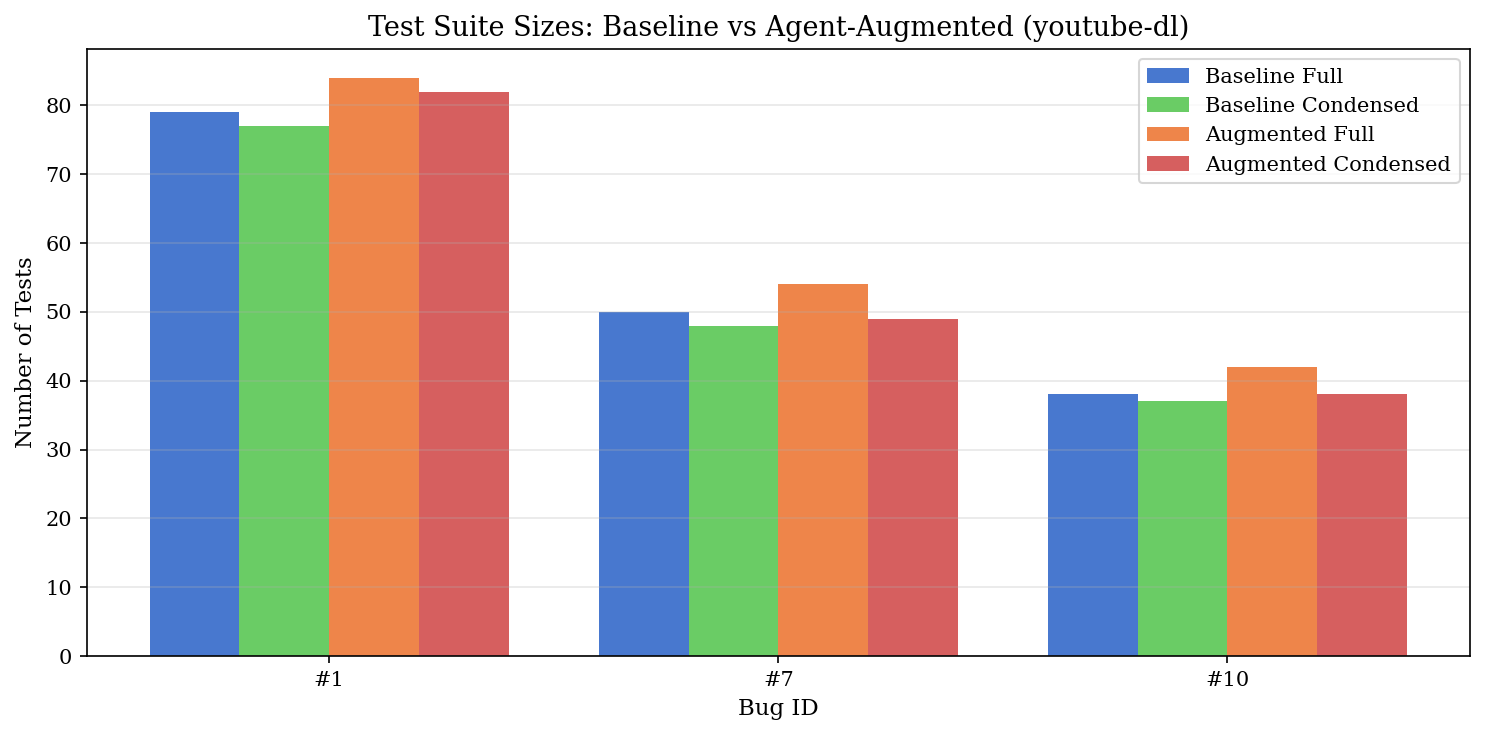

In [6]:
labels = [f"#{bid}" for bid in experiments]
x = np.arange(len(labels))
w = 0.2

fig, ax = plt.subplots(figsize=(10, 5))

vals = {
    "Baseline Full": [],
    "Baseline Condensed": [],
    "Augmented Full": [],
    "Augmented Condensed": [],
}
for bid, exp in experiments.items():
    br = exp["baseline_result"]
    ar = exp["augmented_result"]
    vals["Baseline Full"].append(br.num_tests_full)
    vals["Baseline Condensed"].append(br.num_tests_condensed)
    vals["Augmented Full"].append(ar.num_tests_full if ar else 0)
    vals["Augmented Condensed"].append(ar.num_tests_condensed if ar else 0)

colors = ["#4878CF", "#6ACC65", "#EE854A", "#D65F5F"]
for i, (label, v) in enumerate(vals.items()):
    ax.bar(x + (i - 1.5) * w, v, w, label=label, color=colors[i])

ax.set_xlabel("Bug ID")
ax.set_ylabel("Number of Tests")
ax.set_title(f"Test Suite Sizes: Baseline vs Agent-Augmented ({PROJECT})")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(f"{ARTIFACTS_DIR}/agent_test_suite_sizes.png", bbox_inches="tight")
plt.show()

### 5.2 Rank Comparison: Baseline Condensed vs Augmented Condensed

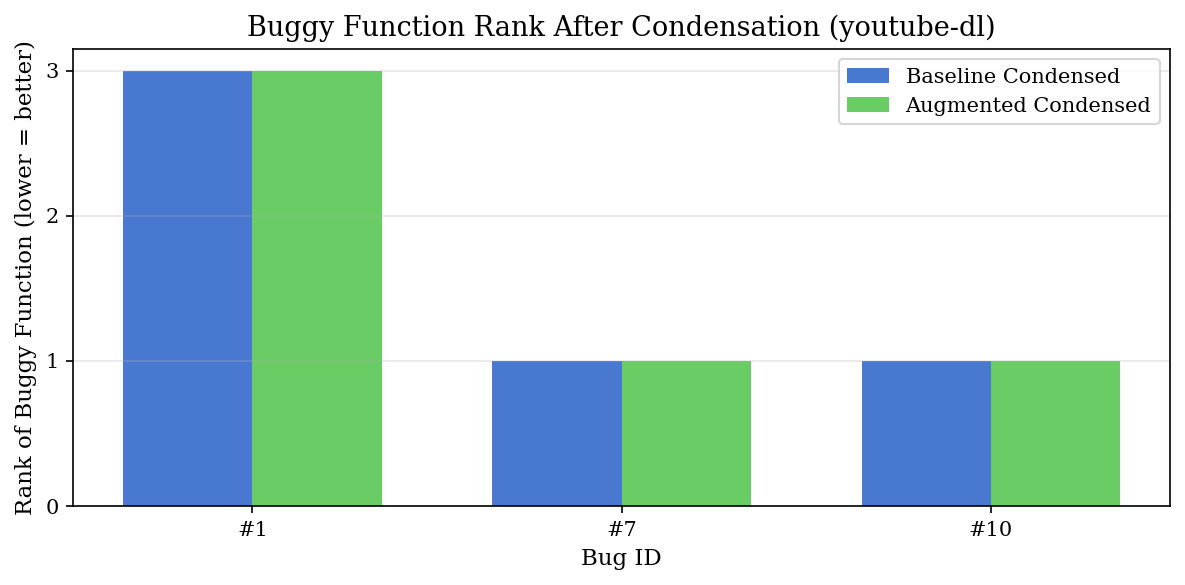

In [7]:
fig, ax = plt.subplots()
w = 0.35

rank_baseline = [exp["baseline_result"].rank_condensed for exp in experiments.values()]
rank_augmented = [
    exp["augmented_result"].rank_condensed if exp["augmented_result"] else 0
    for exp in experiments.values()
]

ax.bar(x - w/2, rank_baseline, w, label="Baseline Condensed", color="#4878CF")
ax.bar(x + w/2, rank_augmented, w, label="Augmented Condensed", color="#6ACC65")

ax.set_xlabel("Bug ID")
ax.set_ylabel("Rank of Buggy Function (lower = better)")
ax.set_title(f"Buggy Function Rank After Condensation ({PROJECT})")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(f"{ARTIFACTS_DIR}/agent_rank_comparison.png", bbox_inches="tight")
plt.show()

### 5.3 Embedding Similarity Heatmaps

For each bug, we embed all existing tests + generated tests using Gemini embeddings and visualize pairwise cosine similarity. Existing tests that form high-similarity clusters indicate redundancy. Agent-generated tests should show lower similarity to existing ones.

[sandbox_WARNING] Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Bug #1: embedding 79 existing + 5 generated tests ...


[sandbox_INFO] HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-001:batchEmbedContents "HTTP/1.1 200 OK"
[sandbox_INFO] HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-001:batchEmbedContents "HTTP/1.1 200 OK"
[sandbox_INFO] HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-001:batchEmbedContents "HTTP/1.1 200 OK"


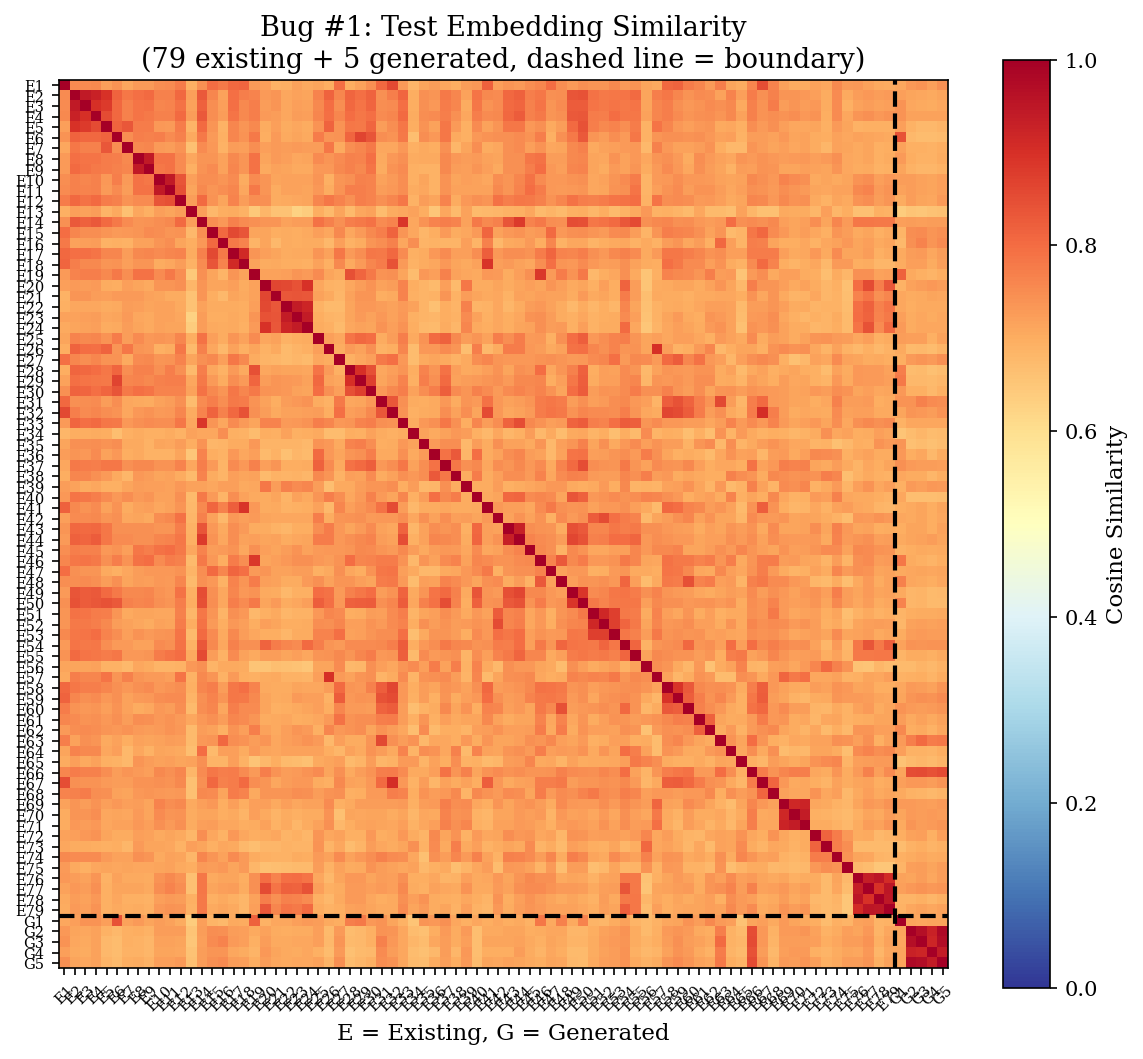

[sandbox_WARNING] Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


  Existing-Existing avg similarity: 0.734
  Existing-Generated avg similarity: 0.711
  Generated-Generated avg similarity: 0.854
Bug #7: embedding 50 existing + 5 generated tests ...


[sandbox_INFO] HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-001:batchEmbedContents "HTTP/1.1 200 OK"
[sandbox_INFO] HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-001:batchEmbedContents "HTTP/1.1 200 OK"


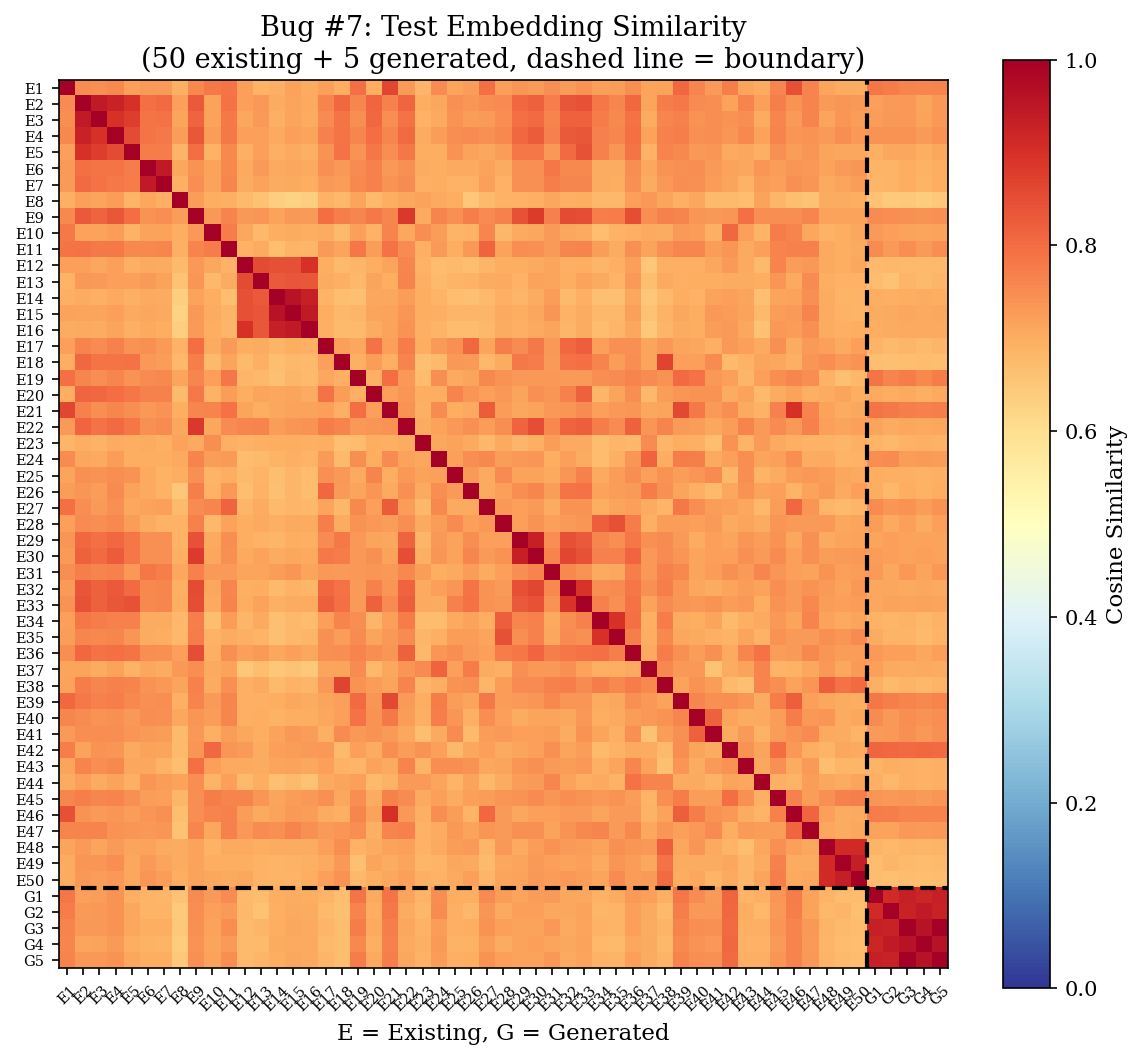

[sandbox_WARNING] Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


  Existing-Existing avg similarity: 0.731
  Existing-Generated avg similarity: 0.713
  Generated-Generated avg similarity: 0.941
Bug #10: embedding 38 existing + 5 generated tests ...


[sandbox_INFO] HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-001:batchEmbedContents "HTTP/1.1 200 OK"


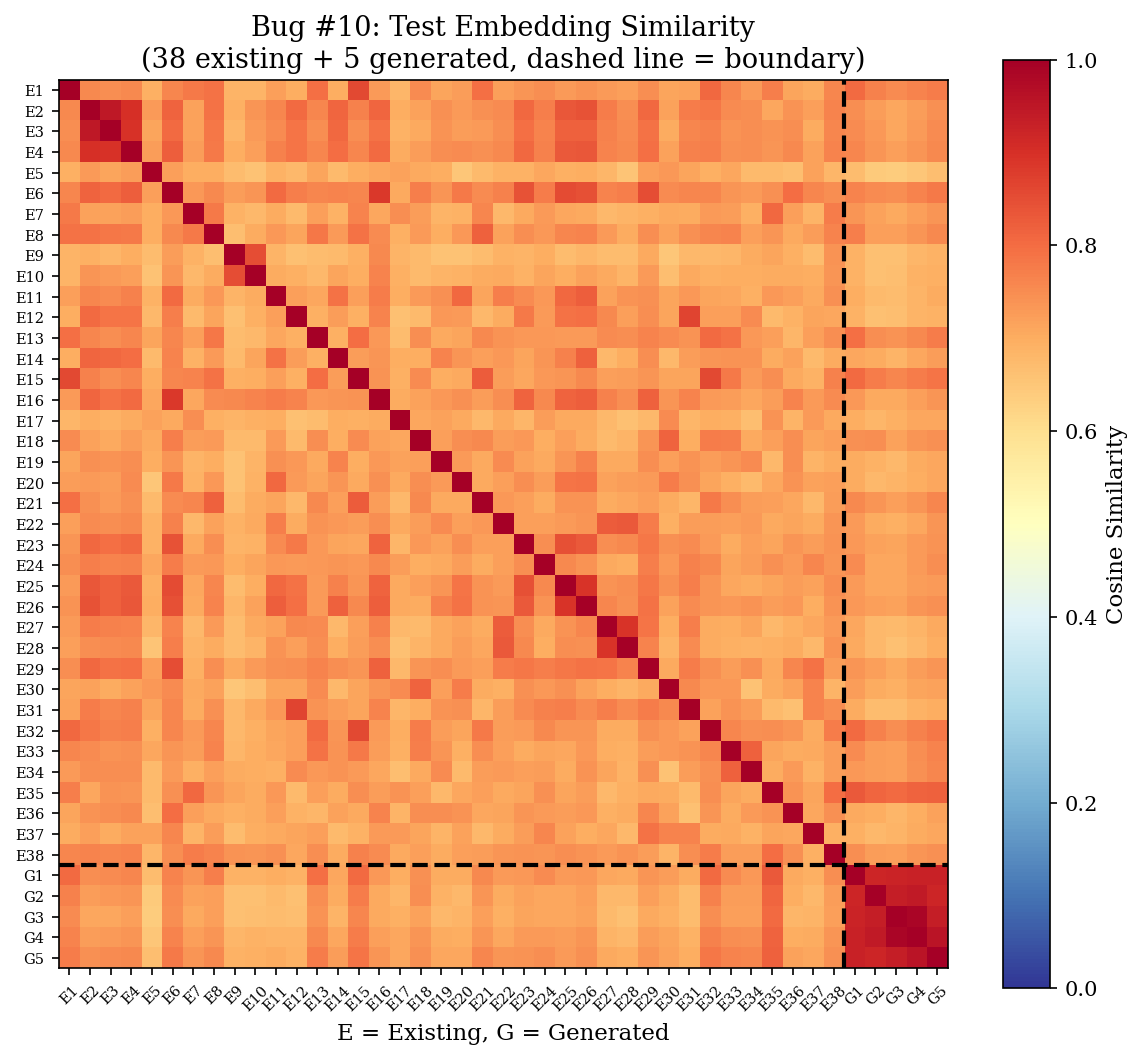

  Existing-Existing avg similarity: 0.733
  Existing-Generated avg similarity: 0.722
  Generated-Generated avg similarity: 0.937


In [8]:
for bid, exp in experiments.items():
    existing_tests = extract_unit_tests(exp["context"].test_code)
    generated_tests = exp["generated_tests"]

    if not existing_tests or not generated_tests:
        print(f"Bug #{bid}: skipping heatmap (no tests)")
        continue

    all_tests = existing_tests + generated_tests
    n_existing = len(existing_tests)
    n_gen = len(generated_tests)

    print(f"Bug #{bid}: embedding {n_existing} existing + {n_gen} generated tests ...")
    sim_matrix = compute_similarity_matrix(all_tests, GOOGLE_API_KEY)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(sim_matrix, cmap="RdYlBu_r", vmin=0, vmax=1, aspect="equal")
    fig.colorbar(im, ax=ax, label="Cosine Similarity")

    # Draw boundary between existing and generated
    ax.axhline(n_existing - 0.5, color="black", linewidth=2, linestyle="--")
    ax.axvline(n_existing - 0.5, color="black", linewidth=2, linestyle="--")

    # Labels
    test_labels = [f"E{i+1}" for i in range(n_existing)] + [f"G{i+1}" for i in range(n_gen)]
    ax.set_xticks(range(len(test_labels)))
    ax.set_xticklabels(test_labels, fontsize=7, rotation=45)
    ax.set_yticks(range(len(test_labels)))
    ax.set_yticklabels(test_labels, fontsize=7)
    ax.set_xlabel("E = Existing, G = Generated")

    ax.set_title(f"Bug #{bid}: Test Embedding Similarity\n"
                 f"({n_existing} existing + {n_gen} generated, dashed line = boundary)")

    fig.tight_layout()
    fig.savefig(f"{ARTIFACTS_DIR}/agent_similarity_heatmap_bug{bid}.png", bbox_inches="tight")
    plt.show()

    # Print summary stats
    existing_block = sim_matrix[:n_existing, :n_existing]
    cross_block = sim_matrix[:n_existing, n_existing:]
    gen_block = sim_matrix[n_existing:, n_existing:]

    mask_e = np.triu(np.ones_like(existing_block, dtype=bool), k=1)
    mask_g = np.triu(np.ones_like(gen_block, dtype=bool), k=1)

    print(f"  Existing-Existing avg similarity: {existing_block[mask_e].mean():.3f}")
    print(f"  Existing-Generated avg similarity: {cross_block.mean():.3f}")
    if n_gen > 1:
        print(f"  Generated-Generated avg similarity: {gen_block[mask_g].mean():.3f}")

### 5.4 Per-Node Suspiciousness: Baseline vs Augmented

Scatter plot showing how each node's suspiciousness changes between baseline-condensed and augmented-condensed suites.

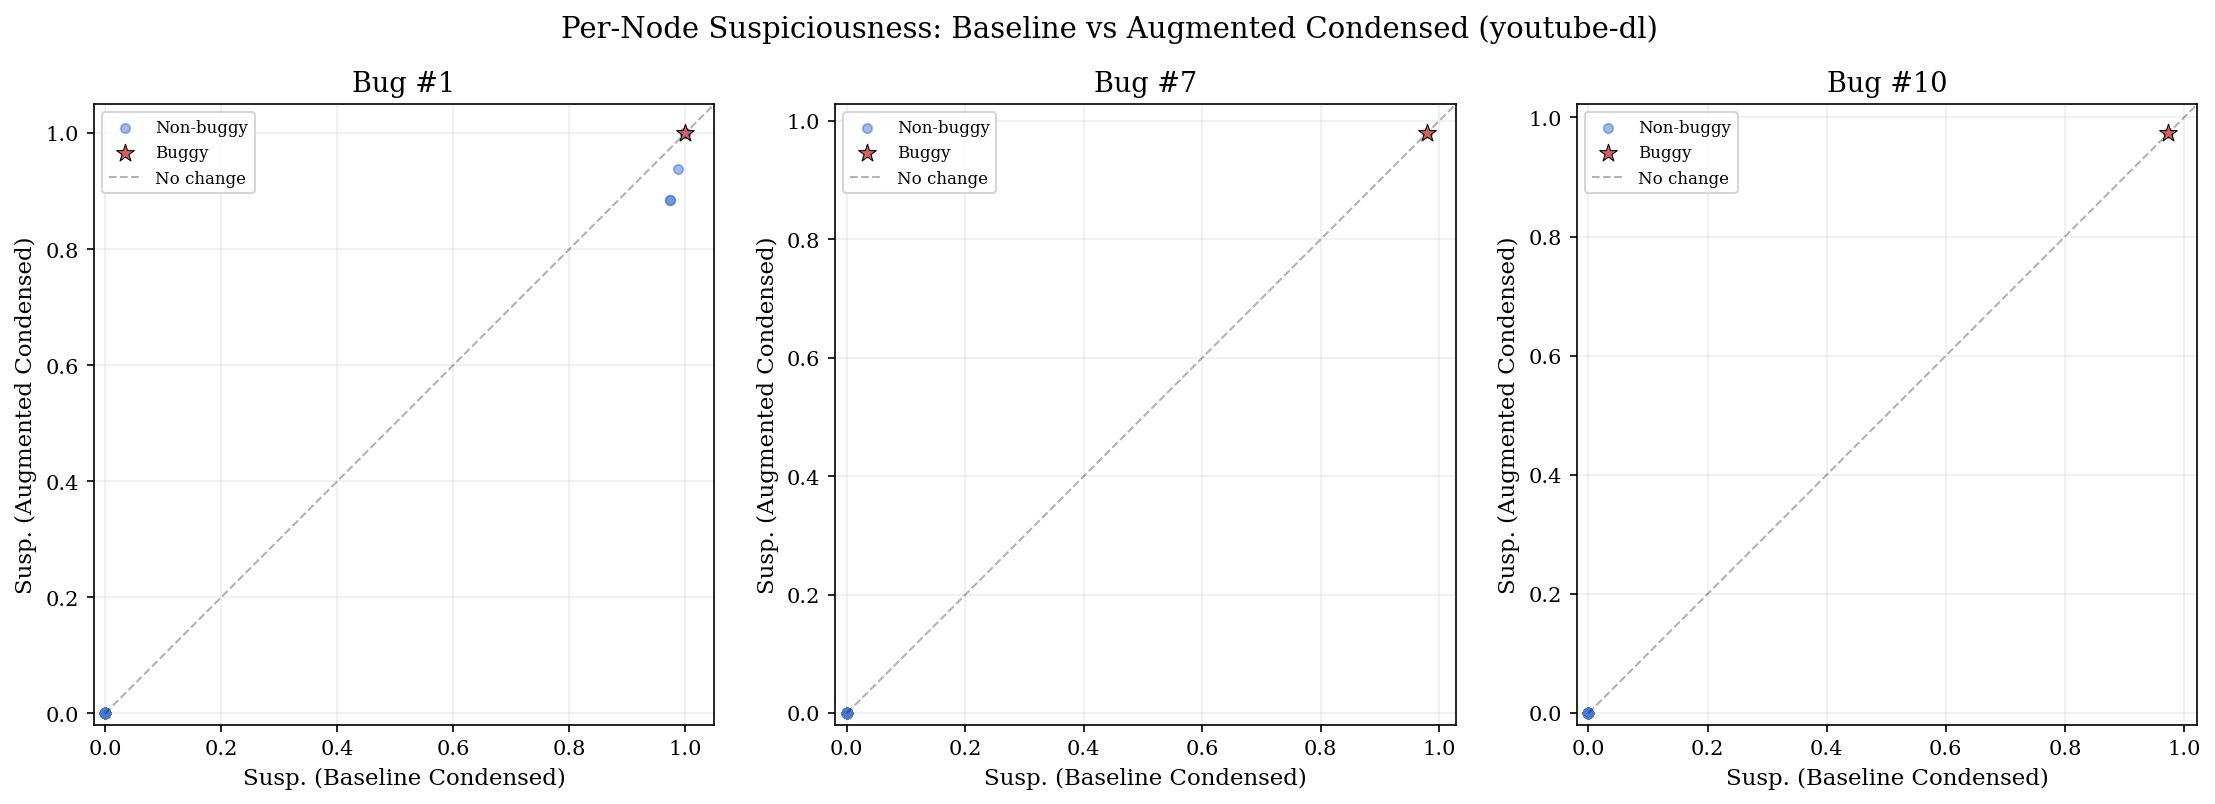

In [9]:
n_bugs = len(experiments)
fig, axes = plt.subplots(1, n_bugs, figsize=(5 * n_bugs, 5), squeeze=False)

for idx, (bid, exp) in enumerate(experiments.items()):
    ax = axes[0, idx]
    br = exp["baseline_result"]
    ar = exp["augmented_result"]
    if not ar:
        ax.text(0.5, 0.5, "No augmented data", ha="center", va="center", transform=ax.transAxes)
        continue

    baseline_cg = exp["baseline_cg"]
    augmented_cg = exp["augmented_cg"]
    nodes_b = baseline_cg["nodes"]
    patch_text = Path(BUGSINPY_ROOT).joinpath("projects", PROJECT, "bugs", bid, "bug_patch.txt").read_text()
    gt_fqns = set(extract_ground_truth_fqns(patch_text, nodes_b))

    all_fqns = [n["fqn"] for n in nodes_b]

    # Baseline condensed scores
    b_tr = baseline_cg["test_results"]
    b_cm = baseline_cg.get("coverage_matrix", {})
    b_cond_tr, b_cond_em = condense_test_suite(b_tr, b_cm)
    b_scores = compute_tarantula(b_cond_tr, b_cond_em, all_fqns)

    # Augmented condensed scores (use augmented call graph's nodes for alignment)
    a_tr = augmented_cg["test_results"]
    a_cm = augmented_cg.get("coverage_matrix", {})
    a_cond_tr, a_cond_em = condense_test_suite(a_tr, a_cm)
    a_all_fqns = [n["fqn"] for n in augmented_cg["nodes"]]
    a_scores = compute_tarantula(a_cond_tr, a_cond_em, a_all_fqns)

    # Plot only nodes present in both
    common = set(b_scores) & set(a_scores)
    buggy_x, buggy_y = [], []
    other_x, other_y = [], []

    for fqn in common:
        bv = b_scores[fqn]
        av = a_scores[fqn]
        if fqn in gt_fqns:
            buggy_x.append(bv); buggy_y.append(av)
        else:
            other_x.append(bv); other_y.append(av)

    ax.scatter(other_x, other_y, s=20, alpha=0.5, color="#4878CF", label="Non-buggy", zorder=2)
    ax.scatter(buggy_x, buggy_y, s=80, color="#D65F5F", marker="*", label="Buggy",
               zorder=3, edgecolors="black", linewidths=0.5)

    lim = max(max(other_x + buggy_x, default=0), max(other_y + buggy_y, default=0)) * 1.05
    lim = max(lim, 0.1)
    ax.plot([0, lim], [0, lim], "k--", alpha=0.3, linewidth=1, label="No change")
    ax.set_xlim(-0.02, lim)
    ax.set_ylim(-0.02, lim)
    ax.set_xlabel("Susp. (Baseline Condensed)")
    ax.set_ylabel("Susp. (Augmented Condensed)")
    ax.set_title(f"Bug #{bid}")
    ax.legend(fontsize=8)
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

fig.suptitle(f"Per-Node Suspiciousness: Baseline vs Augmented Condensed ({PROJECT})", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(f"{ARTIFACTS_DIR}/agent_scatter_comparison.png", bbox_inches="tight")
plt.show()

## 6. Export Results

In [10]:
from datetime import datetime

csv_path = f"{ARTIFACTS_DIR}/agent_experiment_{PROJECT}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
df.to_csv(csv_path, index=False)
print(f"Results saved to {csv_path}")

Results saved to ../condensation_artifacts/agent_experiment_youtube-dl_20260227_145515.csv


## 7. Discussion

### What does the agent add over pure condensation?

The baseline condensation experiment (previous notebook) removes **exact behavioral duplicates** — tests with identical coverage fingerprints. This is provably lossless but only captures redundancy at the function-coverage level.

The test generation agent adds a complementary dimension:

1. **Semantic diversity awareness**: The agent's vector store tracks embedding similarity across all tests. Each new test is generated to be semantically distinct from all previous ones — not just coverage-identical, but conceptually different.

2. **Targeted test generation**: The agent generates tests specifically for the buggy module, increasing the chance that new tests exercise the buggy code path. If a generated test fails on the buggy version, it directly increases $e_f$ for the buggy function in the Tarantula formula.

3. **Test quality enforcement**: The smell-detection loop ensures generated tests follow best practices (single assertion, clear purpose, no magic numbers), producing tests that are individually more informative than randomly generated ones.

### Comparison with baseline condensation

| Aspect | Condensation Only | Agent + Condensation |
|--------|-------------------|---------------------|
| Redundancy detection | Coverage fingerprints (exact) | Coverage + embedding similarity (semantic) |
| Test suite modification | Remove only | Remove + generate |
| Buggy function targeting | None | LLM generates tests for buggy module |
| New failing tests | No | Possible (increases $e_f$) |

### Limitations

- Generated tests may not compile or pass if the LLM produces incorrect assertions or misunderstands the API
- The agent targets the buggy module based on ground truth — in production, the fault localization agent would need to select which module to target
- Docker re-tracing adds ~2 min per bug; this could be optimized with incremental tracing
- Small sample size (2 bugs); a larger study across multiple projects would strengthen the evidence

---

# Experiment 2: Agent Test Suite Replacement (No Condensation)

**Hypothesis:** An LLM-based test generation agent can produce a standalone test suite that, even without algorithmic condensation, achieves better or comparable Tarantula fault-localization rankings than the original human-written test suite.

**Key difference from Experiment 1:** Instead of *augmenting* the original tests and applying condensation, we **replace the passing tests** with agent-generated tests while **always preserving the original failing tests**. We compare raw Tarantula rankings (no condensation) between the original suite and the agent suite.

In [11]:
import ast
import re as _re


def _extract_failing_test_methods(test_code, test_results):
    """
    Parse the original test file and return the source of every test method
    whose name appears in a failing test result.

    test_results keys look like 'ClassName.method_name'; we match on method_name.
    """
    failing_names = {
        k.split(".")[-1] for k, passed in test_results.items() if not passed
    }
    if not failing_names:
        return [], set()

    try:
        tree = ast.parse(test_code)
    except SyntaxError:
        return [], set()

    lines = test_code.splitlines()
    methods = []
    found_names = set()

    for node in ast.walk(tree):
        if isinstance(node, ast.FunctionDef) and node.name in failing_names:
            start = node.lineno - 1
            end = node.end_lineno
            func_lines = lines[start:end]

            base_indent = len(func_lines[0]) - len(func_lines[0].lstrip())
            dedented = []
            for ln in func_lines:
                if not ln.strip():
                    dedented.append("")
                elif len(ln) >= base_indent:
                    dedented.append(ln[base_indent:])
                else:
                    dedented.append(ln.lstrip())
            methods.append("\n".join(dedented))
            found_names.add(node.name)

    return methods, found_names


def build_replacement_test_file(generated_tests, failing_methods, module_import):
    """
    Build a test file that contains:
      1. All original failing test methods (preserved exactly)
      2. Agent-generated tests (replacing the passing tests)
    """
    import_line = f"from {module_import} import *"

    def _indent_method(code):
        return "\n".join(
            "    " + line if line.strip() else ""
            for line in code.splitlines()
        )

    all_methods = []

    for m in failing_methods:
        all_methods.append(_indent_method(m))

    for t in generated_tests:
        all_methods.append(_indent_method(t))

    return (
        f"import unittest\n"
        f"{import_line}\n\n\n"
        f"class AgentReplacementTests(unittest.TestCase):\n"
        + "\n\n".join(all_methods)
        + "\n"
    )


def run_replacement_experiment(
    project, bug_id, n_tests, google_api_key,
    bugsinpy_root, experiments_dir, artifacts_dir,
):
    """
    Experiment 2: Replace original *passing* tests with agent-generated tests,
    but always preserve the original failing tests.
    Compares Tarantula rankings (no condensation) between the original suite
    and the agent + failing-tests suite.
    """
    patch_path = Path(bugsinpy_root) / "projects" / project / "bugs" / bug_id / "bug_patch.txt"
    patch_text = patch_path.read_text()
    agent_config = make_agent_config(google_api_key)

    with BugsInPyDockerSandbox(
        project, bug_id,
        bugsinpy_root=bugsinpy_root,
        experiments_dir=experiments_dir,
    ) as sandbox:
        print(f"  [1/7] Checkout buggy version ...")
        ec, _, err = sandbox.checkout(version=0)
        if ec != 0:
            print(f"  FAIL checkout: {err}")
            return None

        print(f"  [2/7] Compile ...")
        ec, _, err = sandbox.compile(verbose=True)
        if ec != 0:
            print(f"  FAIL compile: {err}")
            return None

        baseline_output = f"call_graph_{project}_{bug_id}.json"
        print(f"  [3/7] Baseline tracer → {baseline_output}")
        ec, _, err = sandbox.run_dynamic_tracer(output_file=baseline_output)
        if ec != 0:
            print(f"  FAIL baseline tracer: {err}")
            return None

        baseline_cg_path = sandbox.host_experiments_dir / project / baseline_output
        with open(baseline_cg_path) as f:
            baseline_cg = json.load(f)
        os.makedirs(artifacts_dir, exist_ok=True)
        shutil.copy2(
            baseline_cg_path,
            Path(artifacts_dir) / f"call_graph_{project}_{bug_id}.json",
        )

        ctx = extract_bug_context(sandbox, baseline_cg, patch_text)
        if not ctx:
            return None
        print(f"  Buggy FQN: {ctx.buggy_fqn}")
        print(f"  Module:    {ctx.module_import}")

        # Save original test file to artifacts
        orig_artifact = Path(artifacts_dir) / f"exp2_original_tests_{project}_{bug_id}.py"
        orig_artifact.write_text(ctx.test_code)
        print(f"  [4/7] Saved original test file → {orig_artifact.name}")

        # Identify and preserve failing tests from baseline
        b_test_results = baseline_cg.get("test_results", {})
        failing_methods, failing_names = _extract_failing_test_methods(
            ctx.test_code, b_test_results,
        )
        n_failing = sum(1 for v in b_test_results.values() if not v)
        print(f"  [5/7] Identified {n_failing} failing tests → preserved {len(failing_methods)} methods: {failing_names}")

        print(f"  [6/7] Generating {n_tests} diverse tests with agent ...")
        generated = generate_diverse_tests(
            ctx.source_code, ctx.test_code, n_tests, agent_config,
        )
        print(f"  Generated {len(generated)} tests")

        if not generated and not failing_methods:
            print("  No tests generated and no failing tests — cannot run experiment")
            return None

        replacement_content = build_replacement_test_file(
            generated, failing_methods, ctx.module_import,
        )
        new_artifact = Path(artifacts_dir) / f"exp2_agent_tests_{project}_{bug_id}.py"
        new_artifact.write_text(replacement_content)
        print(f"  Saved agent test file → {new_artifact.name}")
        print(f"  Final suite: {len(failing_methods)} original failing + {len(generated)} agent-generated")

        # Overwrite the original test file and retrace
        print(f"  [7/7] Replacing passing tests and re-tracing ...")
        replacement_output = f"call_graph_{project}_{bug_id}_replacement.json"
        replacement_cg = inject_and_retrace(
            sandbox, replacement_content,
            ctx.test_file_container, replacement_output,
        )
        if replacement_cg:
            shutil.copy2(
                sandbox.host_experiments_dir / project / replacement_output,
                Path(artifacts_dir) / f"call_graph_{project}_{bug_id}_replacement.json",
            )

    # Compute Tarantula WITHOUT condensation
    print(f"\n  Computing Tarantula rankings (no condensation) ...")
    nodes_b = baseline_cg.get("nodes", [])
    all_fqns_b = [n["fqn"] for n in nodes_b]
    gt_fqns = extract_ground_truth_fqns(patch_text, nodes_b)
    if not gt_fqns:
        print("  Could not extract ground truth FQN")
        return None

    b_tr = baseline_cg.get("test_results", {})
    b_cm = baseline_cg.get("coverage_matrix", {})
    b_exec_map = invert_coverage_matrix(b_cm)
    b_scores = compute_tarantula(b_tr, b_exec_map, all_fqns_b)
    b_rank, b_fqn, b_susp = get_rank(b_scores, gt_fqns)
    print(f"  Baseline (original):  {len(b_tr)} tests, rank={b_rank}, susp={b_susp:.4f}")

    r_scores = {}
    r_rank, r_fqn, r_susp = -1, "", 0.0
    r_n_tests = 0
    if replacement_cg:
        nodes_r = replacement_cg.get("nodes", [])
        all_fqns_r = [n["fqn"] for n in nodes_r]
        r_tr = replacement_cg.get("test_results", {})
        r_cm = replacement_cg.get("coverage_matrix", {})
        r_exec_map = invert_coverage_matrix(r_cm)
        r_scores = compute_tarantula(r_tr, r_exec_map, all_fqns_r)
        r_rank, r_fqn, r_susp = get_rank(r_scores, gt_fqns)
        r_n_tests = len(r_tr)
        print(f"  Replacement (agent):  {r_n_tests} tests, rank={r_rank}, susp={r_susp:.4f}")
        print(f"  Delta:                rank {b_rank - r_rank:+d}")

    return {
        "project": project,
        "bug_id": bug_id,
        "context": ctx,
        "baseline_cg": baseline_cg,
        "replacement_cg": replacement_cg,
        "generated_tests": generated,
        "failing_methods_preserved": failing_methods,
        "gt_fqns": gt_fqns,
        "baseline_scores": b_scores,
        "replacement_scores": r_scores,
        "baseline_rank": b_rank,
        "baseline_susp": b_susp,
        "baseline_fqn": b_fqn,
        "baseline_n_tests": len(b_tr),
        "replacement_rank": r_rank,
        "replacement_susp": r_susp,
        "replacement_fqn": r_fqn,
        "replacement_n_tests": r_n_tests,
        "original_test_artifact": str(orig_artifact),
        "new_test_artifact": str(new_artifact),
    }

## 2.1 Run Replacement Experiments

For each bug, this cell:
1. Starts a Docker container with the buggy version
2. Runs the baseline dynamic tracer on the **original** test suite
3. Extracts relevant code and saves the original test file
4. Identifies **failing tests** from the baseline and preserves them
5. Generates N diverse tests with the LLM agent
6. Builds a new test file: **original failing tests + agent-generated tests** (passing tests are replaced)
7. Re-runs the tracer on the new test suite
8. Computes Tarantula rankings without condensation for both suites

In [12]:
exp2 = {}

for bid in BUG_IDS:
    print(f"\n{'='*70}")
    print(f"  Experiment 2 — {PROJECT} #{bid}")
    print(f"{'='*70}")

    result = run_replacement_experiment(
        project=PROJECT,
        bug_id=bid,
        n_tests=N_TESTS_PER_BUG,
        google_api_key=GOOGLE_API_KEY,
        bugsinpy_root=BUGSINPY_ROOT,
        experiments_dir=EXPERIMENTS_DIR,
        artifacts_dir=ARTIFACTS_DIR,
    )

    if result:
        exp2[bid] = result
        print(f"\n  Baseline:    rank={result['baseline_rank']}, susp={result['baseline_susp']:.4f}")
        print(f"  Replacement: rank={result['replacement_rank']}, susp={result['replacement_susp']:.4f}")
    else:
        print(f"  FAILED")

print(f"\n✓ {len(exp2)}/{len(BUG_IDS)} experiments completed.")

[sandbox_INFO] Starting container python:3.11-slim in detached mode...



  Experiment 2 — youtube-dl #1


[sandbox_INFO] Container 47b14366174eb821581cfd6b997173bdcc84758c331cf842485a9d1f7aeb725c started
[sandbox_INFO] Installing BugsInPy dependencies in container...


Hit:1 http://deb.debian.org/debian trixie InRelease
Get:2 http://deb.debian.org/debian trixie-updates InRelease [47.3 kB]
Get:3 http://deb.debian.org/debian-security trixie-security InRelease [43.4 kB]
Get:4 http://deb.debian.org/debian trixie/main arm64 Packages [9607 kB]
Get:5 http://deb.debian.org/debian trixie-updates/main arm64 Packages [5404 B]
Get:6 http://deb.debian.org/debian-security trixie-security/main arm64 Packages [113 kB]
Fetched 9817 kB in 2s (5324 kB/s)
Reading package lists...
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  git-man krb5-locales less libbrotli1 libcbor0.10 libcom-err2
  libcurl3t64-gnutls libedit2 liberror-perl libexpat1 libfido2-1
  libgdbm-compat4t64 libgnutls30t64 libgssapi-krb5-2 libidn2-0 libk5crypto3
  libkeyutils1 libkrb5-3 libkrb5support0 libldap-common libldap2 libnghttp2-14
  libnghttp3-9 libngtcp2-16 libngtcp2-crypto-gnutls8 libp11-kit0 libperl5.40
  li

[sandbox_INFO] Checking out youtube-dl bug 1 (version 0)...


...

[sandbox_INFO] HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-001:batchEmbedContents "HTTP/1.1 200 OK"
[sandbox_INFO] Node: write_initial_test | Inputs: code_to_test=#!/usr/bin/env python
# coding: utf-8

from __future__ import unicode_literals

import base64
import binascii
import calendar
import codecs
import contextlib
import ctypes
import datetime
import email.utils
import email.header
import errno
import functools
import gzip
import io
import itertools
import json
import locale
import math
import operator
import os
import platform
import random
import re
import socket
import ssl
import subprocess
import sys
import tempfile
import traceback
import xml.etree.ElementTree
import zlib

from .compat import (

# ... (truncated) ...

    protocol = info_dict.get('protocol')
    if protocol is not None:
        return protocol

    url = info_dict['url']
    if url.startswith('rtmp'):
        return 'rtmp'
    elif url.startswith('mms'):
       

    ✓ Generated: def test_determine_protocol_rtmp_url(self):
  Generated 5 tests
  Saved agent test file → exp2_agent_tests_youtube-dl_1.py
  Final suite: 1 original failing + 5 agent-generated
  [7/7] Replacing passing tests and re-tracing ...
  Injected augmented tests → test_utils.py
  Re-running dynamic tracer → call_graph_youtube-dl_1_replacement.json
  Tracer failed: Could not find test_file info


[sandbox_ERROR] Error stopping container: 500 Server Error for http+docker://localhost/v1.47/containers/47b14366174eb821581cfd6b997173bdcc84758c331cf842485a9d1f7aeb725c?v=False&link=False&force=False: Internal Server Error ("write /var/lib/desktop-containerd/daemon/io.containerd.metadata.v1.bolt/meta.db: input/output error: unknown")
[sandbox_INFO] Starting container python:3.11-slim in detached mode...



  Computing Tarantula rankings (no condensation) ...
  Baseline (original):  79 tests, rank=3, susp=1.0000

  Baseline:    rank=3, susp=1.0000
  Replacement: rank=-1, susp=0.0000

  Experiment 2 — youtube-dl #7


APIError: 500 Server Error for http+docker://localhost/v1.47/images/python:3.11-slim/json: Internal Server Error ("rpc error: code = Unknown desc = blob sha256:0b23cfb7425d065008b778022a17b1551c82f8b4866ee5a7a200084b7e2eafbf expected at /var/lib/desktop-containerd/daemon/io.containerd.content.v1.content/blobs/sha256/0b23cfb7425d065008b778022a17b1551c82f8b4866ee5a7a200084b7e2eafbf: open /var/lib/desktop-containerd/daemon/io.containerd.content.v1.content/blobs/sha256/0b23cfb7425d065008b778022a17b1551c82f8b4866ee5a7a200084b7e2eafbf: input/output error")

## 2.2 Generated Tests

Display the agent-generated tests for each bug (these **replace** the original suite entirely).

In [ ]:
for bid, exp in exp2.items():
    display(Markdown(f"### Bug #{bid} — `{exp['context'].buggy_fqn}`"))
    preserved = exp.get("failing_methods_preserved", [])
    if preserved:
        display(Markdown(f"**Preserved failing tests ({len(preserved)}):**"))
        for i, m in enumerate(preserved, 1):
            display(Markdown(f"*Failing test {i}:*\n```python\n{m}\n```"))
    display(Markdown(f"**Agent-generated tests ({len(exp['generated_tests'])}):**"))
    for i, test in enumerate(exp["generated_tests"], 1):
        display(Markdown(f"*Generated test {i}:*\n```python\n{test}\n```"))
    display(Markdown(f"*Original test file saved to:* `{exp['original_test_artifact']}`"))
    display(Markdown(f"*Agent test file saved to:* `{exp['new_test_artifact']}`"))

## 2.3 Results Summary

In [ ]:
rows2 = []
for bid, exp in exp2.items():
    rows2.append({
        "bug_id": bid,
        "buggy_fqn": exp["baseline_fqn"].split(".")[-1],
        "tests_baseline": exp["baseline_n_tests"],
        "tests_replacement": exp["replacement_n_tests"],
        "rank_baseline": exp["baseline_rank"],
        "rank_replacement": exp["replacement_rank"],
        "susp_baseline": round(exp["baseline_susp"], 4),
        "susp_replacement": round(exp["replacement_susp"], 4),
        "delta_rank": exp["baseline_rank"] - exp["replacement_rank"],
        "generated_tests": len(exp["generated_tests"]),
    })

df2 = pd.DataFrame(rows2)
df2.style.set_caption(f"Experiment 2: Original vs Agent-Replacement — {PROJECT}")

## 2.4 Visualizations

### 2.4.1 Test Suite Sizes: Original vs Agent-Replacement

In [ ]:
labels2 = [f"#{bid}" for bid in exp2]
x2 = np.arange(len(labels2))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
n_baseline = [exp["baseline_n_tests"] for exp in exp2.values()]
n_replacement = [exp["replacement_n_tests"] for exp in exp2.values()]

ax.bar(x2 - w / 2, n_baseline, w, label="Original Suite", color="#4878CF")
ax.bar(x2 + w / 2, n_replacement, w, label="Agent Suite", color="#6ACC65")

ax.set_xlabel("Bug ID")
ax.set_ylabel("Number of Tests")
ax.set_title(f"Test Suite Sizes: Original vs Agent-Replacement ({PROJECT})")
ax.set_xticks(x2)
ax.set_xticklabels(labels2)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(f"{ARTIFACTS_DIR}/exp2_test_suite_sizes.png", bbox_inches="tight")
plt.show()

### 2.4.2 Rank Comparison: Original vs Agent-Replacement

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
w = 0.35

rank_orig = [exp["baseline_rank"] for exp in exp2.values()]
rank_repl = [exp["replacement_rank"] for exp in exp2.values()]

ax.bar(x2 - w / 2, rank_orig, w, label="Original Suite", color="#4878CF")
ax.bar(x2 + w / 2, rank_repl, w, label="Agent Suite", color="#6ACC65")

ax.set_xlabel("Bug ID")
ax.set_ylabel("Rank of Buggy Function (lower = better)")
ax.set_title(f"Buggy Function Rank: Original vs Agent-Replacement ({PROJECT})")
ax.set_xticks(x2)
ax.set_xticklabels(labels2)
ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(f"{ARTIFACTS_DIR}/exp2_rank_comparison.png", bbox_inches="tight")
plt.show()

### 2.4.3 Embedding Similarity Heatmaps

Cosine similarity among all agent-generated tests (using Gemini embeddings). Lower inter-test similarity indicates the agent produced semantically diverse tests.

In [ ]:
for bid, exp in exp2.items():
    tests = exp["generated_tests"]
    if len(tests) < 2:
        print(f"Bug #{bid}: not enough tests for heatmap")
        continue

    test_labels = [f"agent_{i+1}" for i in range(len(tests))]
    sim_matrix = compute_similarity_matrix(tests, GOOGLE_API_KEY)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(sim_matrix, cmap="YlOrRd", vmin=0, vmax=1)
    ax.set_xticks(range(len(test_labels)))
    ax.set_xticklabels(test_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(test_labels)))
    ax.set_yticklabels(test_labels, fontsize=8)
    for i in range(len(test_labels)):
        for j in range(len(test_labels)):
            ax.text(j, i, f"{sim_matrix[i, j]:.2f}",
                    ha="center", va="center", fontsize=7,
                    color="white" if sim_matrix[i, j] > 0.7 else "black")
    fig.colorbar(im, ax=ax, label="Cosine Similarity")
    ax.set_title(f"Agent Test Similarity — Bug #{bid}")
    fig.tight_layout()
    fig.savefig(f"{ARTIFACTS_DIR}/exp2_similarity_heatmap_bug{bid}.png", bbox_inches="tight")
    plt.show()

### 2.4.4 Per-Node Suspiciousness: Original vs Agent-Replacement

Scatter plot of Tarantula suspiciousness for each code node — original suite (x-axis) vs agent suite (y-axis). Points above the diagonal indicate the agent suite assigns *higher* suspiciousness; the buggy function is highlighted.

In [ ]:
n_bugs = len(exp2)
fig, axes = plt.subplots(1, max(n_bugs, 1), figsize=(5 * max(n_bugs, 1), 5), squeeze=False)

for idx, (bid, exp) in enumerate(exp2.items()):
    ax = axes[0, idx]
    gt = set(exp["gt_fqns"])
    b_scores = exp["baseline_scores"]
    r_scores = exp["replacement_scores"]

    if not r_scores:
        ax.text(0.5, 0.5, "No replacement data",
                ha="center", va="center", transform=ax.transAxes)
        continue

    common = set(b_scores) & set(r_scores)
    buggy_x, buggy_y = [], []
    other_x, other_y = [], []
    for fqn in common:
        bv = b_scores[fqn]
        rv = r_scores[fqn]
        if fqn in gt:
            buggy_x.append(bv); buggy_y.append(rv)
        else:
            other_x.append(bv); other_y.append(rv)

    ax.scatter(other_x, other_y, s=20, alpha=0.5, color="#4878CF",
               label="Non-buggy", zorder=2)
    ax.scatter(buggy_x, buggy_y, s=80, color="#D65F5F", marker="*",
               label="Buggy", zorder=3, edgecolors="black", linewidths=0.5)

    lim = max(max(other_x + buggy_x, default=0),
              max(other_y + buggy_y, default=0)) * 1.05
    lim = max(lim, 0.1)
    ax.plot([0, lim], [0, lim], "k--", alpha=0.3, linewidth=1, label="No change")
    ax.set_xlim(-0.02, lim)
    ax.set_ylim(-0.02, lim)
    ax.set_xlabel("Susp. (Original Suite)")
    ax.set_ylabel("Susp. (Agent Suite)")
    ax.set_title(f"Bug #{bid}")
    ax.legend(fontsize=8)
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

fig.suptitle(
    f"Per-Node Suspiciousness: Original vs Agent-Replacement ({PROJECT})",
    fontsize=14, y=1.02,
)
fig.tight_layout()
fig.savefig(f"{ARTIFACTS_DIR}/exp2_scatter_comparison.png", bbox_inches="tight")
plt.show()

### 2.4.5 Per-Node Suspiciousness Comparison (nodes with susp > 0)

A paired bar chart comparing original vs agent suspiciousness for every node that has a non-zero score in either suite. The buggy node is highlighted in red.

In [ ]:
for bid, exp in exp2.items():
    gt = set(exp["gt_fqns"])
    b_scores = exp["baseline_scores"]
    r_scores = exp["replacement_scores"]
    if not r_scores:
        continue

    common = set(b_scores) & set(r_scores)
    nodes = sorted(
        [f for f in common if b_scores[f] > 0 or r_scores[f] > 0],
        key=lambda f: max(b_scores[f], r_scores[f]),
        reverse=True,
    )
    if not nodes:
        continue

    short_labels = [f.split(".")[-1] for f in nodes]
    is_buggy = [f in gt for f in nodes]
    b_vals = [b_scores[f] for f in nodes]
    r_vals = [r_scores[f] for f in nodes]

    y = np.arange(len(nodes))
    h = 0.35

    fig, ax = plt.subplots(figsize=(10, max(3, len(nodes) * 0.45)))
    bars_orig = ax.barh(y + h / 2, b_vals, h, label="Original suite", color="#4878CF")
    bars_agent = ax.barh(y - h / 2, r_vals, h, label="Agent suite", color="#6ACC65")

    for i, buggy in enumerate(is_buggy):
        if buggy:
            ax.barh(y[i] + h / 2, b_vals[i], h, color="#D65F5F", edgecolor="black", linewidth=0.8)
            ax.barh(y[i] - h / 2, r_vals[i], h, color="#D65F5F", edgecolor="black", linewidth=0.8)
            short_labels[i] = f"★ {short_labels[i]}"

    ax.set_yticks(y)
    ax.set_yticklabels(short_labels, fontsize=8)
    ax.set_xlabel("Tarantula Suspiciousness")
    ax.set_title(f"Bug #{bid} — Per-Node Suspiciousness (nodes with susp > 0)")
    ax.legend(fontsize=9)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    fig.savefig(f"{ARTIFACTS_DIR}/exp2_node_suspiciousness_bug{bid}.png", bbox_inches="tight")
    plt.show()

## 2.5 Export Results

In [ ]:
csv_path = f"{ARTIFACTS_DIR}/exp2_results_{PROJECT}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
df2.to_csv(csv_path, index=False)
print(f"Results saved to {csv_path}")

print("\nArtifact files:")
for bid, exp in exp2.items():
    print(f"  Bug #{bid}:")
    print(f"    Original tests: {exp['original_test_artifact']}")
    print(f"    Agent tests:    {exp['new_test_artifact']}")

## 2.6 Discussion

### What does Experiment 2 measure?

Unlike Experiment 1 (which *augments* the original tests and applies condensation), Experiment 2 asks: **can the agent produce passing tests that, combined with the original failing tests, achieve better fault localization than the full original suite?**

Original failing tests are always preserved because Tarantula requires at least one failing test to produce non-zero suspiciousness scores.

### Key comparison

| Aspect | Original Suite | Agent-Replacement Suite |
|--------|---------------|------------------------|
| Test count | All human-written tests | Original failing tests + N agent-generated tests |
| Failing tests | Included | Always preserved from original |
| Passing tests | All original | Replaced by agent-generated |
| Test diversity | Organically grown, may have redundancy | Explicitly diversity-optimized via vector store |
| Condensation | None | None |

### Interpretation

- A **lower or equal rank** for the agent suite means the agent-generated passing tests provide a cleaner signal for Tarantula than the original passing tests.
- A **higher rank** would indicate the original passing tests contribute useful localization signal that the agent's diversity-optimized tests cannot replicate.
- The **suspiciousness scatter plot** shows whether the agent redistributes suspiciousness in a way that better separates buggy from non-buggy code.

### Limitations

1. **Small sample size** — only tested on a few bugs from a single project.
2. **Module targeting relies on ground truth** — the agent is pointed at the correct module.
3. **Few generated tests** — the agent produces N tests vs. a potentially larger original suite.
4. **Docker overhead** — each bug requires a fresh container build.